# Импорты и вспомогательные функции

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import shapiro
plt.style.use('ggplot')

In [2]:
def plot_with_target(df, name, ax=None, print_bounds=True):
    ax = ax or plt.gca()
    y = df['rings']
    X = df[name].values
    y_unique = y.unique()
    y_unique.sort()

    X_avg = df.groupby('rings')[name].mean()
    ax.scatter(x=y, y=X)
    ax.plot(y_unique, X_avg, color='black', linewidth=3, label='Среднее по кольцам')
    ax.set_xlabel('rings')
    ax.set_ylabel(name)
    ax.set_title(f'{name} vs rings')
    ax.legend(loc='lower right')
    upper_bound, lower_bound = calc_IQR(df, name, print_bounds)
    ax.axhline(y=lower_bound, color='black', linestyle='--')
    ax.axhline(y=upper_bound, color='black', linestyle='--')

In [3]:
def is_normal(df, name):
    stat, p = shapiro(df[name])
    print('P-value:', p)
    if p > 0.05:
        print('Нормальное распределение')
    else:
        print('Не нормальное распределение')

In [4]:
def calc_IQR(df, name, print_bounds=True, coef=1.5):
    y = df[name]
    Q1 = np.quantile(y, 0.25)
    Q3 = np.quantile(y, 0.75)
    IQR = Q3 - Q1
    upper_bound = Q3 + coef * IQR
    lower_bound = Q1 - coef * IQR
    if print_bounds:
        print('Верхняя граница:', upper_bound)
        print('Нижняя граница:', lower_bound)
    return upper_bound, lower_bound

In [5]:
def hist_box_plot(df, title, bins=50):
    y = df[title].values
    fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))
    plt.text(1.5, 0, df[title].describe())
    plt.suptitle(title)
    ax[0].hist(y, bins=bins, density=True)
    ax[1].boxplot(y)
    plt.show()

# 1. Загрузка и первичный осмотр

### Загрузка датасета

In [6]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/abalone/abalone.data"

column_names = ["sex", "length", "diameter", "height", "whole weight", 
                "shucked weight", "viscera weight", "shell weight", "rings"]
df = pd.read_csv(url, names=column_names)

### 5 первых и 5 последних строк

In [7]:
df.head()

,sex,length,diameter,height,whole weight,shucked weight,viscera weight,shell weight,rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


In [8]:
df.tail()

,sex,length,diameter,height,whole weight,shucked weight,viscera weight,shell weight,rings
4172,F,0.565,0.450,0.165,0.8870,0.3700,0.2390,0.2490,11
4173,M,0.590,0.440,0.135,0.9660,0.4390,0.2145,0.2605,10
4174,M,0.600,0.475,0.205,1.1760,0.5255,0.2875,0.3080,9
4175,F,0.625,0.485,0.150,1.0945,0.5310,0.2610,0.2960,10
4176,M,0.710,0.555,0.195,1.9485,0.9455,0.3765,0.4950,12


### Размер датасета

In [9]:
df.shape

(4177, 9)

### Типы данных

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4177 entries, 0 to 4176
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   sex             4177 non-null   str    
 1   length          4177 non-null   float64
 2   diameter        4177 non-null   float64
 3   height          4177 non-null   float64
 4   whole weight    4177 non-null   float64
 5   shucked weight  4177 non-null   float64
 6   viscera weight  4177 non-null   float64
 7   shell weight    4177 non-null   float64
 8   rings           4177 non-null   int64  
dtypes: float64(7), int64(1), str(1)
memory usage: 293.8 KB


**1 категориальный, 7 числовых + целочисленный целевой**

In [11]:
df.dtypes

sex                   str
length            float64
diameter          float64
height            float64
whole weight      float64
shucked weight    float64
viscera weight    float64
shell weight      float64
rings               int64
dtype: object

### Проверка на пропуски

In [12]:
df.isnull().sum()

sex               0
length            0
diameter          0
height            0
whole weight      0
shucked weight    0
viscera weight    0
shell weight      0
rings             0
dtype: int64

**Пропусков нет**

# 2. Анализ целевой переменной

### Гистограмма и боксплот

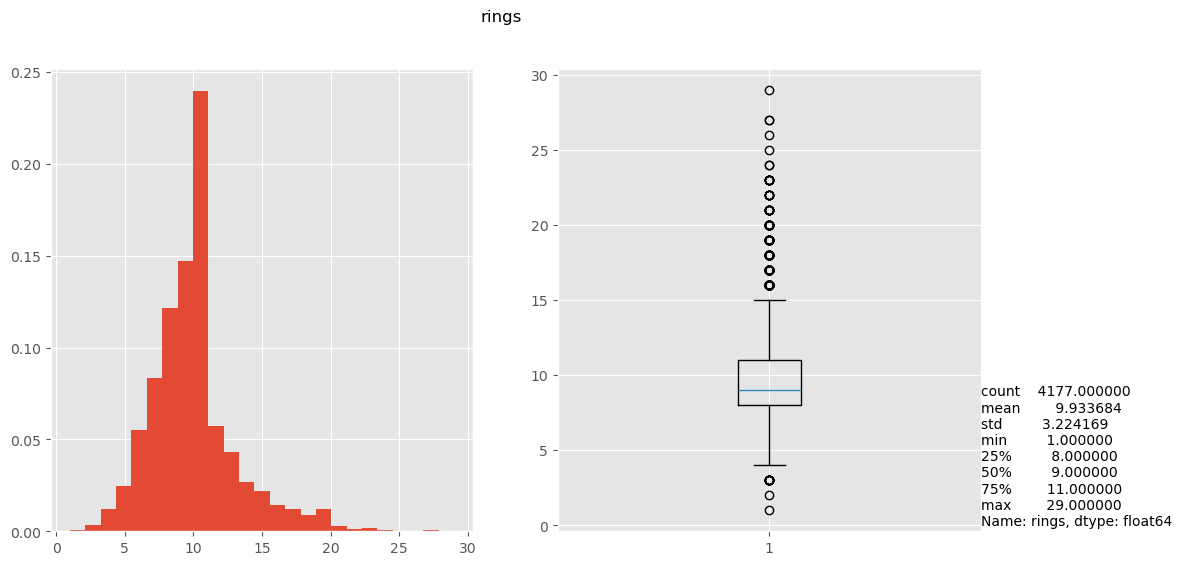

In [13]:
hist_box_plot(df, 'rings', bins=25)

In [14]:
upper_bound, lower_bound = calc_IQR(df, 'rings', coef=3)

Верхняя граница: 20.0
Нижняя граница: -1.0


In [15]:
print('Количество маленьких моллюсков:', df[df['rings'] < 4].shape[0])
print('Количество долгоживущих моллюсков:', df[df['rings'] > 20].shape[0])

Количество маленьких моллюсков: 17
Количество долгоживущих моллюсков: 36


Распределение нормальным не назвал бы из-за наличия долгожителей. Моллюски в среднем живут до 15 лет, но при хороших условиях могут дожить до 30. У нас моллюски с возрастом от 1 до 29. Возраст большинства приходится на 8-12 лет. 

Если судить по box plot и интерквартильному размаху, то все моллюски старше 20 можно считать выбросами. Но поскольку в природе они вполне себе встречаются, пока что удалять не станем.

In [16]:
is_normal(df, 'rings')

P-value: 3.2591499915524437e-40
Не нормальное распределение


# Вывод: распределение не нормальное. Большинство приходится на 8-10 колец. Потенциальные выбросы: больше 20-22 колец. Пока не удалены, посмотрим на них в будущем

# 3. Анализ числовых признаков

## length

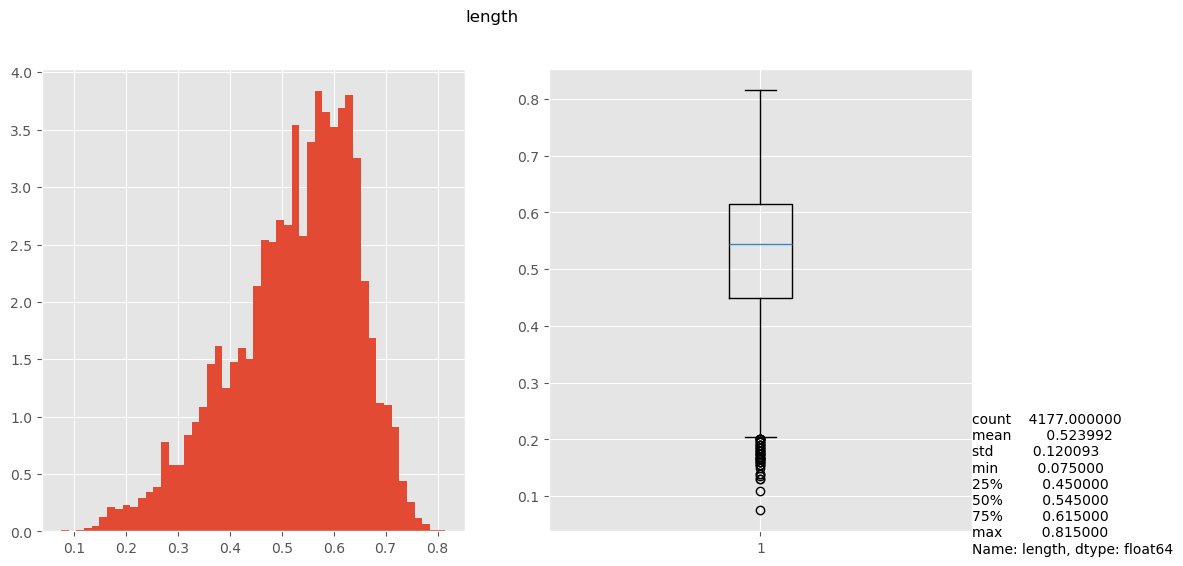

In [17]:
hist_box_plot(df, 'length')

In [18]:
small_length = df[df['length'] < 0.2]['rings']
small_length.describe()

count    43.000000
mean      3.953488
std       1.022450
min       1.000000
25%       3.000000
50%       4.000000
75%       4.500000
max       6.000000
Name: rings, dtype: float64

**Выбросом считается длина меньше 0.2, но и соотвуствует она молодым моллюскам**

**Выбросов в большую сторону нет. Вероятно связано с тем что с возрастом скорость роста моллюска замедляется**

Верхняя граница: 0.8624999999999999
Нижняя граница: 0.20250000000000004


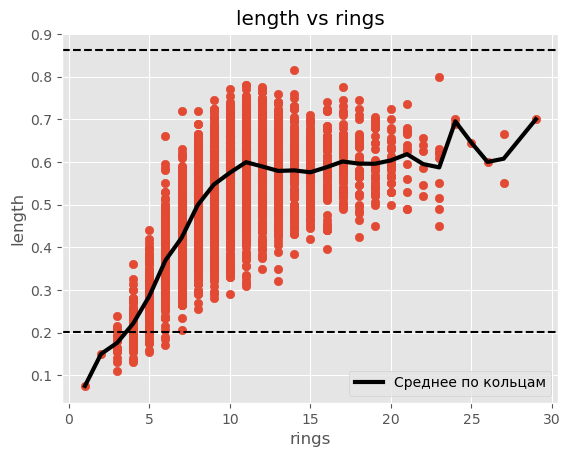

In [19]:
plot_with_target(df, 'length')

In [20]:
is_normal(df, 'length')

P-value: 7.442088788878909e-29
Не нормальное распределение


## diameter

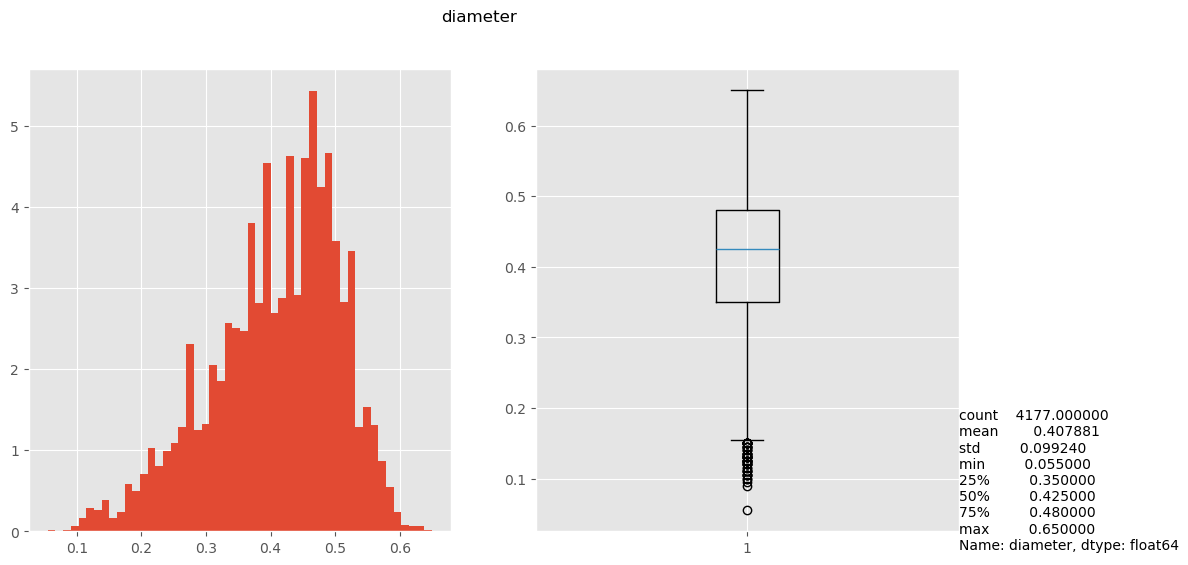

In [21]:
hist_box_plot(df, 'diameter')

**Похожая ситуация с length как на левом, так и на правом графиках. Выбросы в меньшую сторону приходятся на молодых моллюсков, выбросов в большую сторону нет**

In [22]:
small_diameter = df[df['length'] < 0.18]
small_diameter.describe()

,length,diameter,height,whole weight,shucked weight,viscera weight,shell weight,rings
count,28.000000,28.000000,28.000000,28.000000,28.000000,28.000000,28.000000,28.000000
mean,0.154464,0.112857,0.036607,0.020179,0.007446,0.004732,0.006321,3.821429
std,0.022622,0.016241,0.016219,0.007523,0.002910,0.001974,0.002842,1.020297
min,0.075000,0.055000,0.010000,0.002000,0.001000,0.000500,0.001500,1.000000
25%,0.147500,0.105000,0.025000,0.014875,0.005375,0.003375,0.005000,3.000000
50%,0.160000,0.115000,0.035000,0.020250,0.007500,0.004500,0.005000,4.000000
75%,0.170000,0.125000,0.040000,0.024125,0.009500,0.006125,0.008000,4.000000
max,0.175000,0.135000,0.095000,0.034000,0.013000,0.008500,0.014000,6.000000


Верхняя граница: 0.675
Нижняя граница: 0.15499999999999997


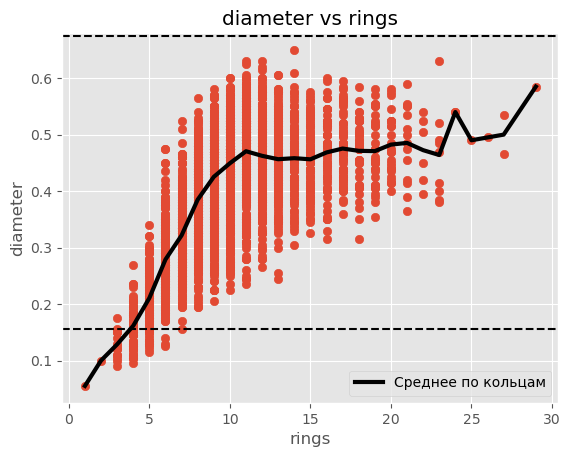

In [23]:
plot_with_target(df, 'diameter')

In [24]:
is_normal(df, 'diameter')

P-value: 1.648334179932697e-28
Не нормальное распределение


## height

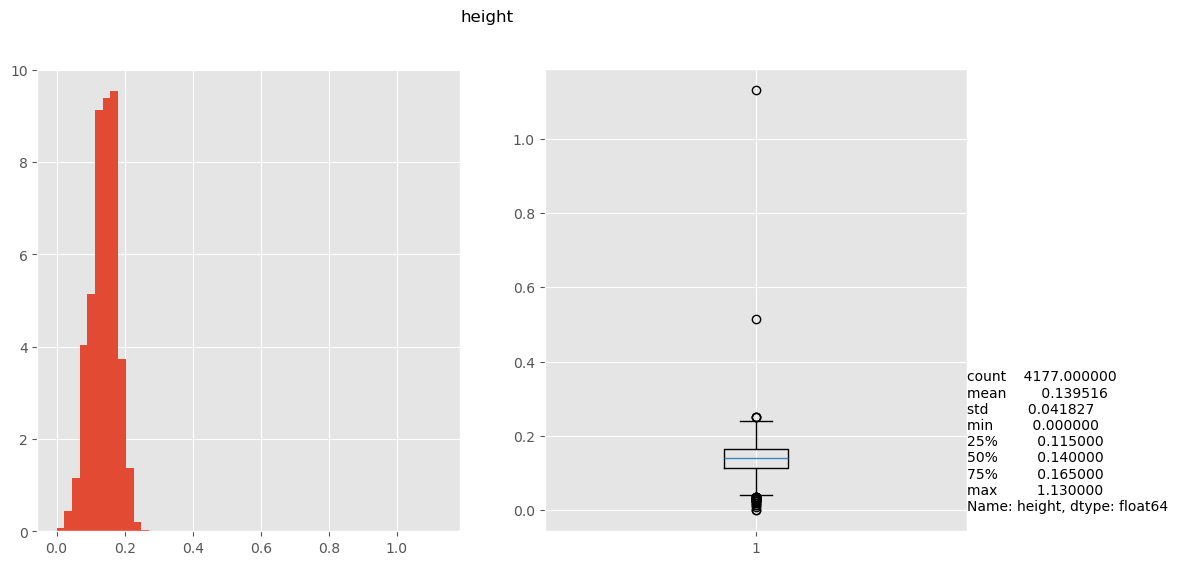

In [25]:
hist_box_plot(df, 'height')

**Видно выбросы в меньшую сторону + сильные выбросы в большую**

In [26]:
upper_bound, lower_bound = calc_IQR(df, 'height')

Верхняя граница: 0.24000000000000002
Нижняя граница: 0.039999999999999994


In [27]:
big_height = df[df['height'] > upper_bound]
big_height

,sex,length,diameter,height,whole weight,shucked weight,viscera weight,shell weight,rings
1417,M,0.705,0.565,0.515,2.2100,1.1075,0.4865,0.5120,10
1428,F,0.815,0.650,0.250,2.2550,0.8905,0.4200,0.7975,14
1763,M,0.775,0.630,0.250,2.7795,1.3485,0.7600,0.5780,12
2051,F,0.455,0.355,1.130,0.5940,0.3320,0.1160,0.1335,8
2179,F,0.595,0.470,0.250,1.2830,0.4620,0.2475,0.4450,14


**Несколько моллюсков на самом краю верхней границы (0.25), их можно оставить**

**C высотой 0.515 и 1.13 удалю**

In [28]:
df = df[df['height'] <= 0.250]
df.shape  # удалились 2 записи

(4175, 9)

**Под нижней границей есть значения равные нулю и очень близкие к нему**

Верхняя граница: 0.24000000000000002
Нижняя граница: 0.039999999999999994


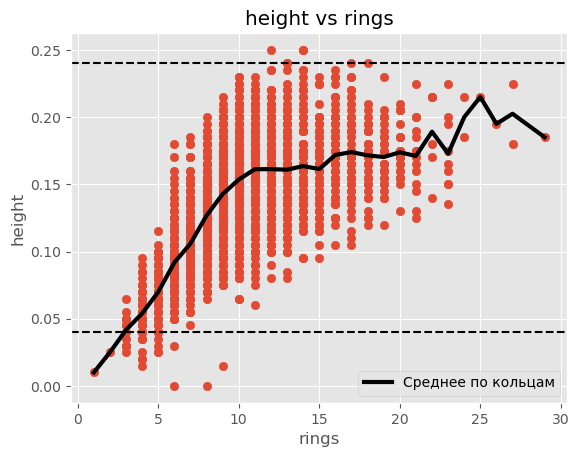

In [29]:
plot_with_target(df, 'height')

In [30]:
small_height = df[df['height'] < lower_bound][['height', 'rings']]
small_height

,height,rings
236,0.010,1
237,0.030,3
238,0.030,3
239,0.035,5
306,0.030,3
694,0.020,4
718,0.035,4
719,0.025,2
720,0.025,3
1174,0.015,9


In [31]:
df[df['height'] <= lower_bound].shape[0]

24

**На всякий случай отсеку моллюсков под нижней границей, т.к. записей не так много, но среди них есть нулевые.**

In [32]:
df = df[df['height'] >= lower_bound]
df.shape  # удалил 24 записи

(4151, 9)

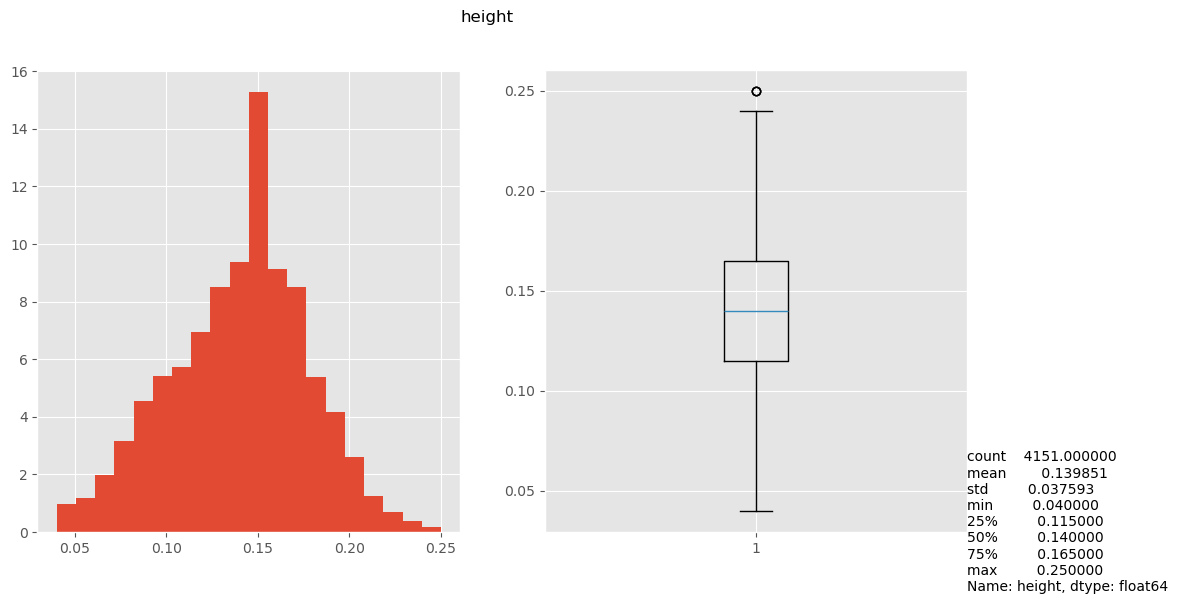

In [33]:
hist_box_plot(df, 'height', bins=20)

In [34]:
is_normal(df, 'height')

P-value: 3.028943330375669e-13
Не нормальное распределение


## whole weight

**У whole weight и других weight признаков должна быть большая корреляция**

In [35]:
df[['whole weight', 'shucked weight', 'viscera weight', 'shell weight']] # проверка, что whole weight это не сумма трёх столбцов

,whole weight,shucked weight,viscera weight,shell weight
0,0.5140,0.2245,0.1010,0.1500
1,0.2255,0.0995,0.0485,0.0700
2,0.6770,0.2565,0.1415,0.2100
3,0.5160,0.2155,0.1140,0.1550
4,0.2050,0.0895,0.0395,0.0550
...,...,...,...,...
4172,0.8870,0.3700,0.2390,0.2490
4173,0.9660,0.4390,0.2145,0.2605
4174,1.1760,0.5255,0.2875,0.3080
4175,1.0945,0.5310,0.2610,0.2960


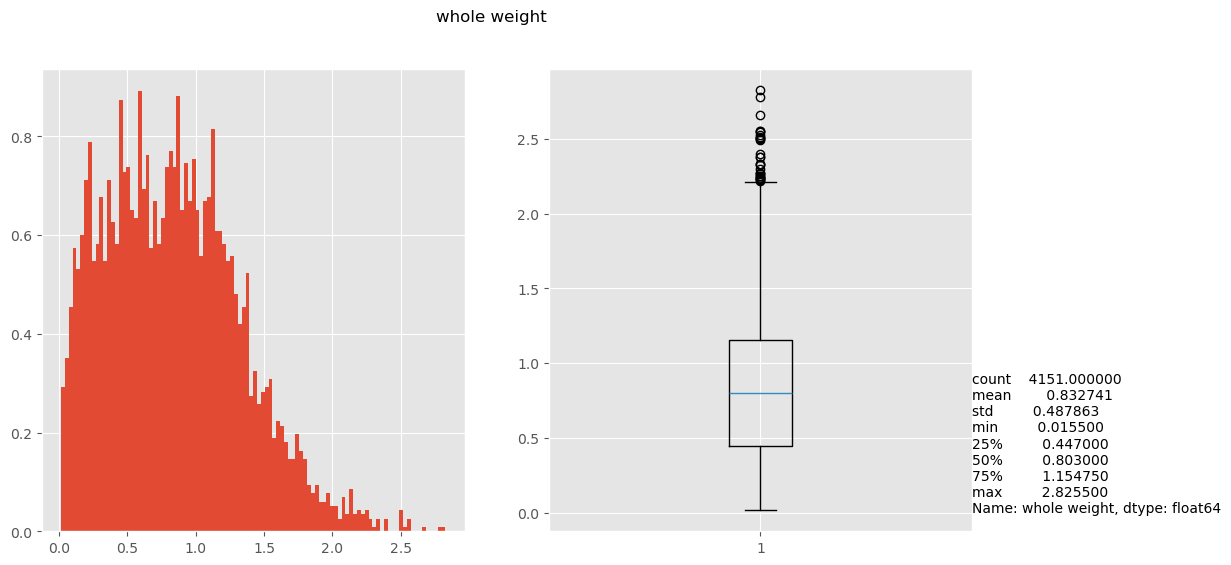

In [36]:
hist_box_plot(df, 'whole weight', bins=100)

Верхняя граница: 2.2163749999999998
Нижняя граница: -0.6146249999999998


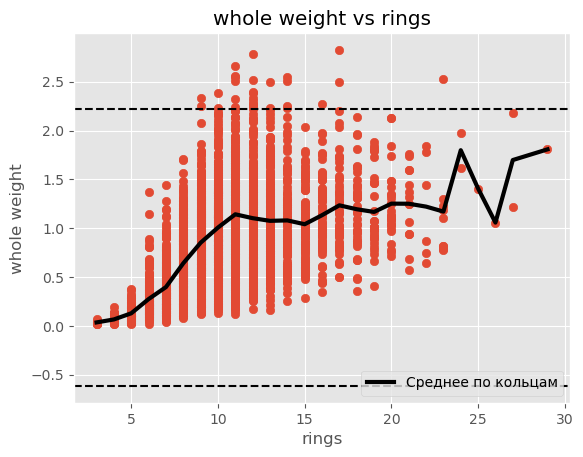

In [37]:
plot_with_target(df, 'whole weight')
plt.show()

In [38]:
big_weight = df[df['whole weight'] > upper_bound]
big_weight[['whole weight', 'shucked weight', "viscera weight", "shell weight", "rings"]].describe()

,whole weight,shucked weight,viscera weight,shell weight,rings
count,3649.000000,3649.000000,3649.000000,3649.000000,3649.000000
mean,0.927129,0.401945,0.201968,0.266603,10.463689
std,0.443352,0.203575,0.100125,0.126111,3.037749
min,0.240500,0.068000,0.032500,0.035000,5.000000
25%,0.574500,0.240500,0.123500,0.169000,8.000000
50%,0.877500,0.375000,0.190000,0.255000,10.000000
75%,1.207500,0.526500,0.264500,0.344000,12.000000
max,2.825500,1.488000,0.760000,1.005000,29.000000


**У моллюсков с большим whole weight достаточно большие числа и в других столбцах с весом, то есть значения взялись не просто так**

**Чисто статистические выбросы есть, но биологически всё в пределах разумного, не удаляю**

In [39]:
is_normal(df, 'whole weight')

P-value: 7.228013607015132e-28
Не нормальное распределение


## shucked weight

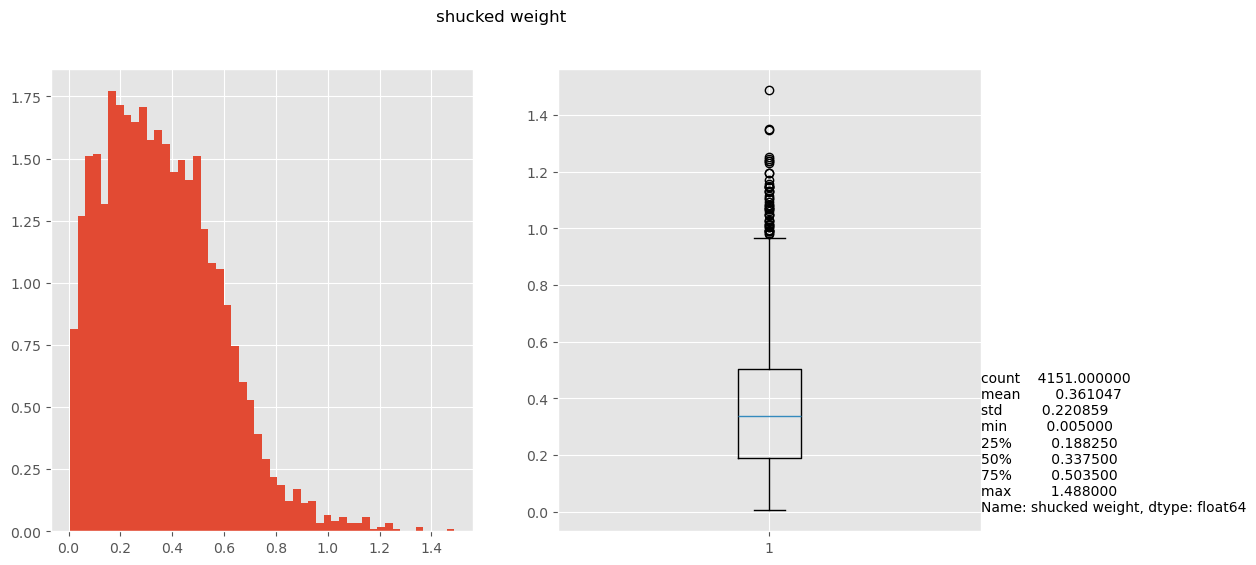

In [40]:
hist_box_plot(df, 'shucked weight')

Верхняя граница: 0.9763749999999998
Нижняя граница: -0.2846249999999999


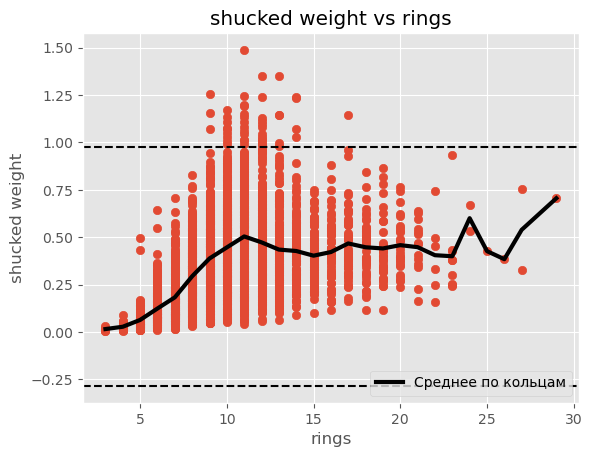

In [41]:
plot_with_target(df, 'shucked weight')

**Аналогично с прошлым**

In [42]:
is_normal(df, 'shucked weight')

P-value: 7.527826970512393e-32
Не нормальное распределение


## viscera weight

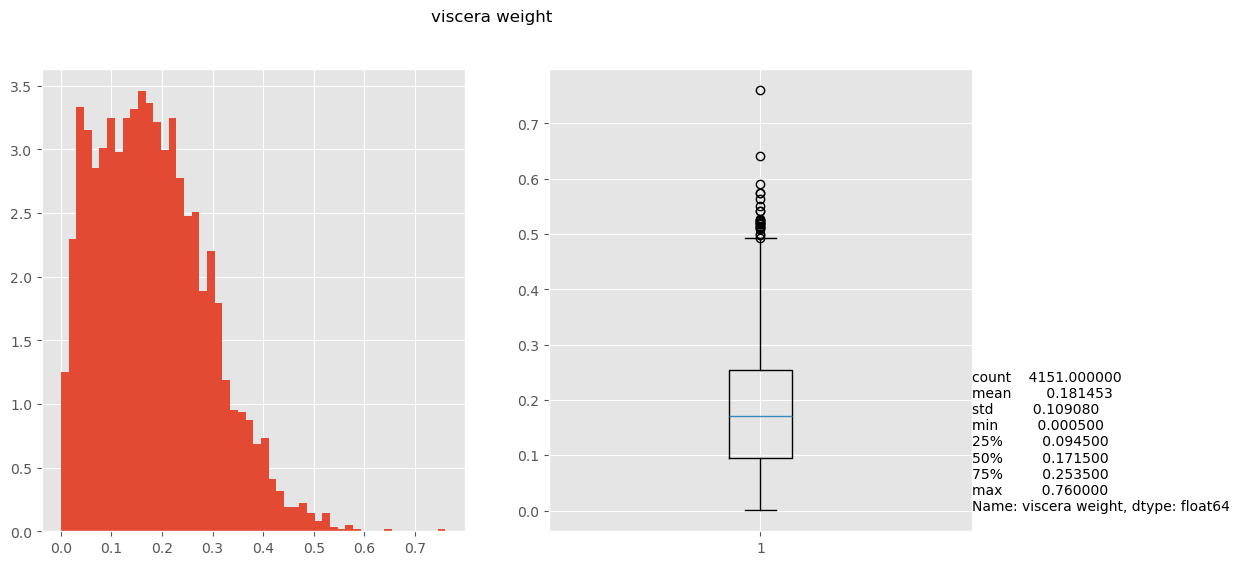

In [43]:
hist_box_plot(df, 'viscera weight')

Верхняя граница: 0.492
Нижняя граница: -0.144


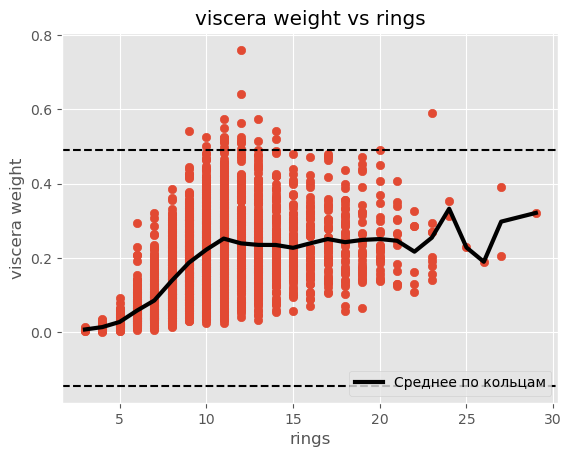

In [44]:
plot_with_target(df, 'viscera weight')

In [45]:
is_normal(df, 'viscera weight')

P-value: 1.382300576921134e-29
Не нормальное распределение


## shell weight

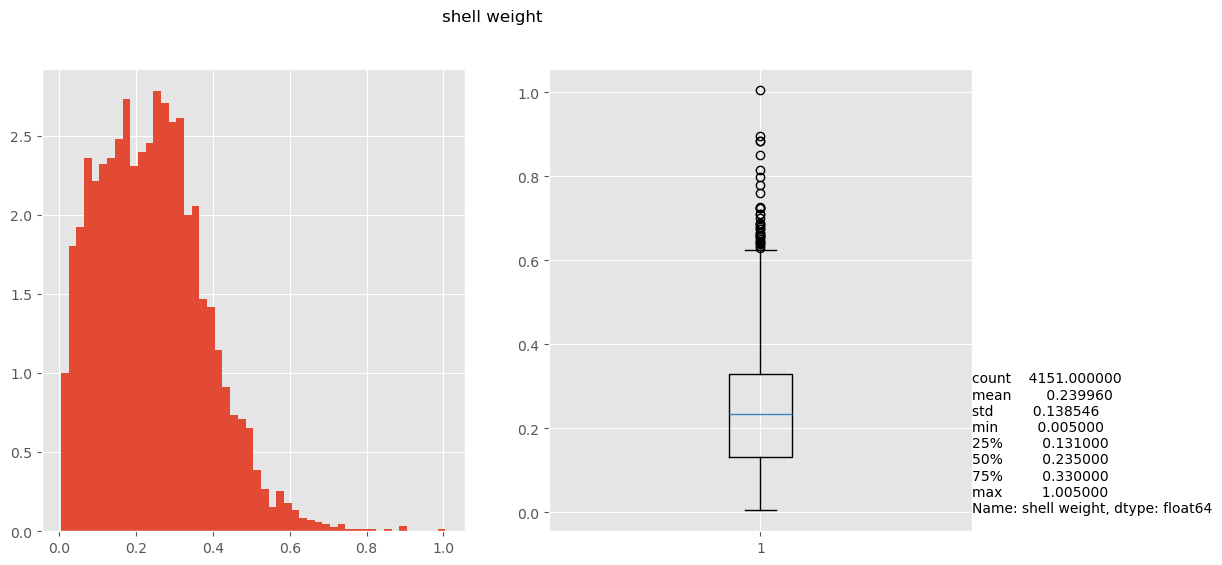

In [46]:
hist_box_plot(df, 'shell weight')

Верхняя граница: 0.6285000000000001
Нижняя граница: -0.16749999999999998


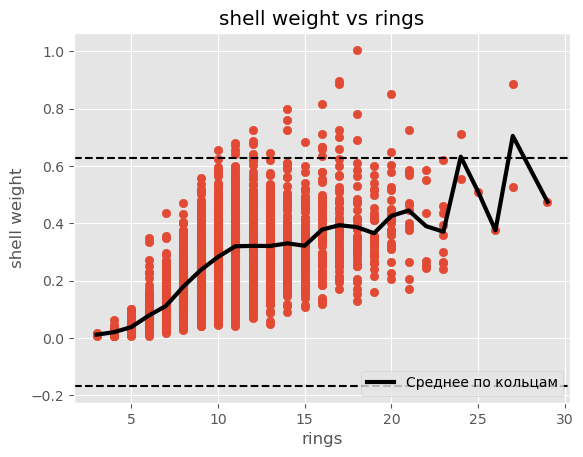

In [47]:
plot_with_target(df, 'shell weight')

In [48]:
is_normal(df, 'shell weight')

P-value: 8.178621502964382e-29
Не нормальное распределение


## Все числовые фичи вместе

In [62]:
numeric_features = column_names[1:-1] # все числовые признаки
numeric_features

['length',
 'diameter',
 'height',
 'whole weight',
 'shucked weight',
 'viscera weight',
 'shell weight']

**Для эксперимента можно попробовать добавить новые признаки**

In [63]:
df['shell ratio'] = df['shell weight'] / (df['whole weight'] + 1e-6)

df['volume'] = df['length'] * df['diameter'] * df['height']

numeric_features.append('shell ratio')
numeric_features.append('volume')

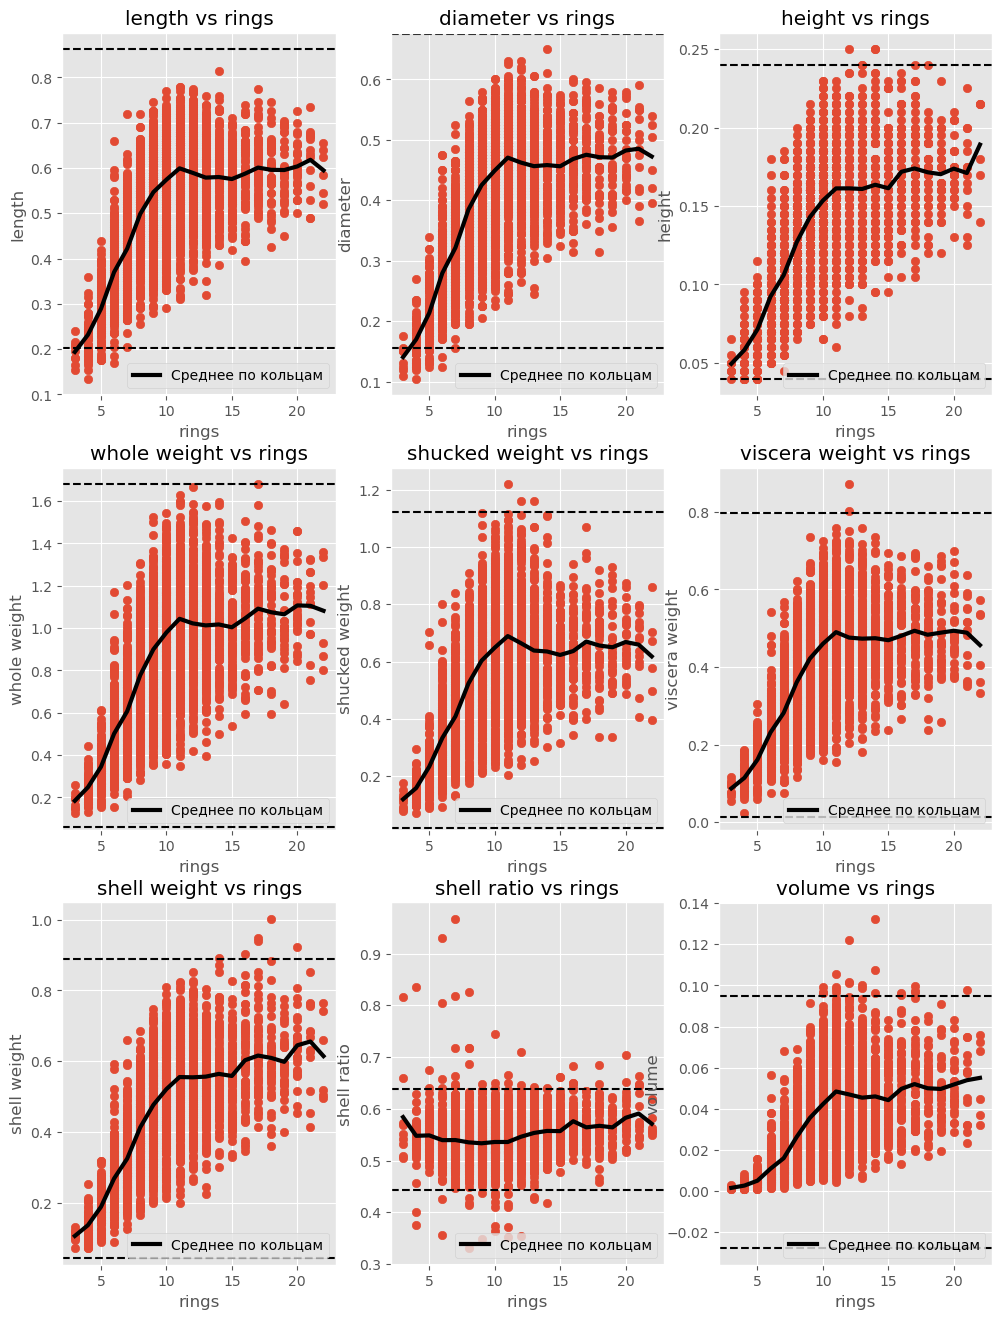

In [65]:
fig, ax = plt.subplots(nrows=3, ncols=3, figsize=(12, 16))
for i in range(len(numeric_features)):
    row = i // 3
    col = i % 3
    plot_with_target(
        df,
        numeric_features[i],
        ax[row][col],
        print_bounds=False
    )   

In [52]:
df[df['rings'] > 22].shape

(16, 11)

**Если судить по средему, то везде похожая картинка. Быстрый рост до 8-11 колец, затем замедление как в росте, так и в весе**

**После 20-22 среднее сильно колеблется, т.к. данных мало. Вероятно лучше будет их удалить**

**Отношение веса панциря ко всему весу почти не меняется**

In [53]:
df = df[df['rings'] <= 22]
df.shape  # удалил 16 записей

(4135, 11)

**Визуально зависимость веса от колец больше похожа на квадратичную зависимость, чем линейную. Можно заменить столбцы с весом на корень**

In [54]:
weight_cols = [col for col in column_names if 'weight' in col]
weight_cols

['whole weight', 'shucked weight', 'viscera weight', 'shell weight']

In [55]:
for col in weight_cols:
    df[col] = np.sqrt(df[col])
df['volume'] = np.sqrt(df['volume'])  # для объёма та же логика

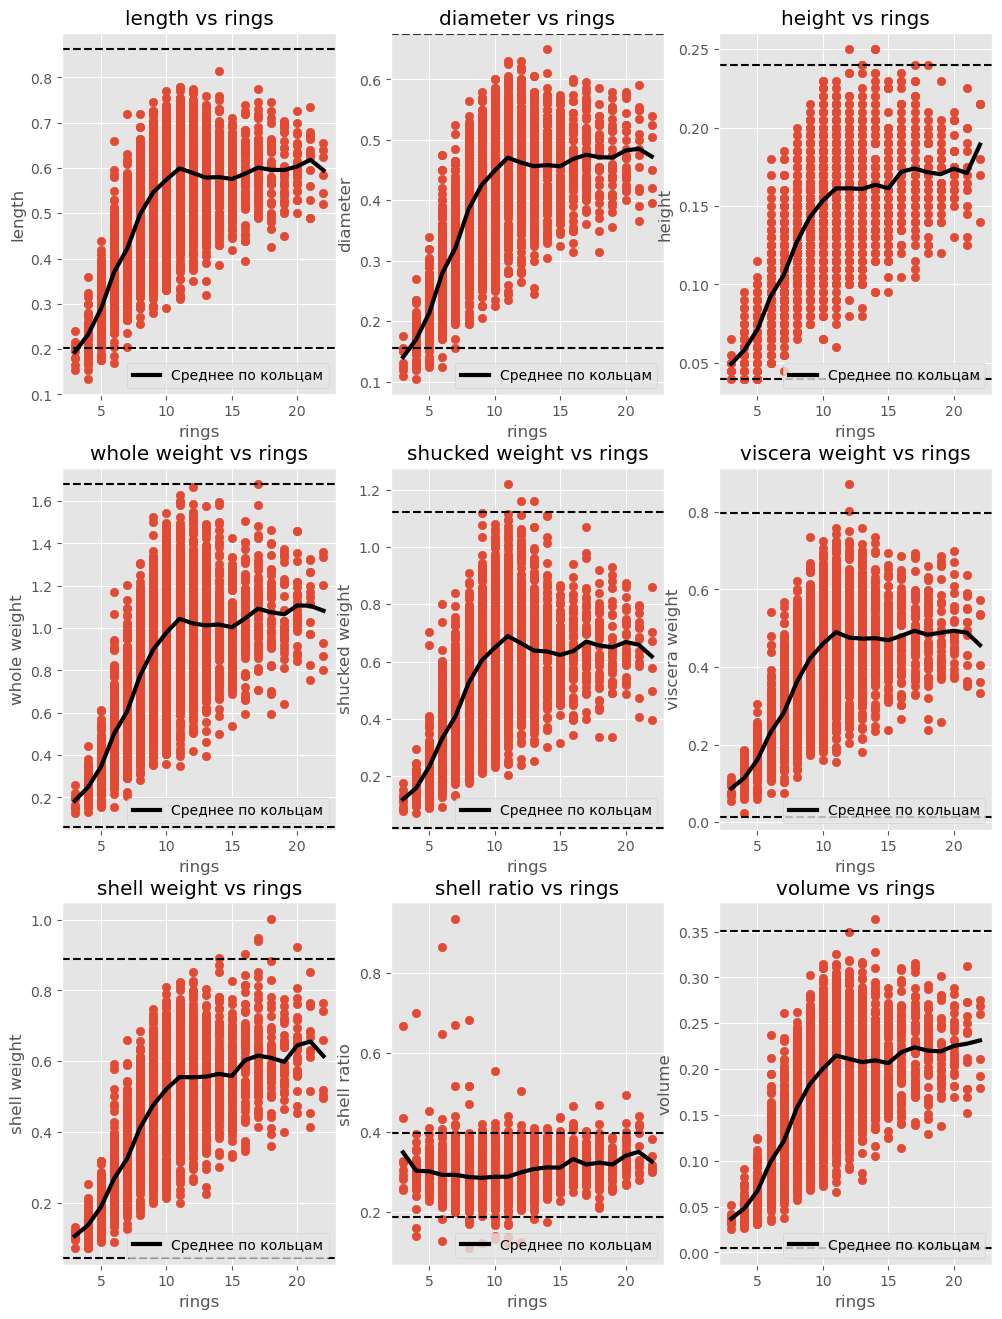

In [56]:
fig, ax = plt.subplots(nrows=3, ncols=3, figsize=(12, 16))
for i in range(len(numeric_features)):
    row = i // 3
    col = i % 3
    plot_with_target(
        df,
        numeric_features[i],
        ax[row][col],
        print_bounds=False
    )

**Теперь все зависимости похожи на линейные**

# Вывод: нормально распределённых данных нет: у признаков, связанных с весом, есть небольшой хвост вправо. Хвоста влево нет, так как там 0.  

# У "геометрических" признаков больше скос вправо: длинный хвост слева и короткий справа. Вероятно связано с тем, что после 8-10 лет у моллюсков заканчивается активный рост

# На последних графиках явно видно, что скорее всего у всех числовых признаков будет сильная корреляция, следовательно бОльшую часть признаков придётся убрать. Масштабирование понадобится, т.к. признаки веса в несколько раз больше признаков, связанных с длиной и высотой

# 4. Анализ категориальных признаков

## Категориальный признак только один и всего 3 категории, для визуализации лучше подойдёт pie plot

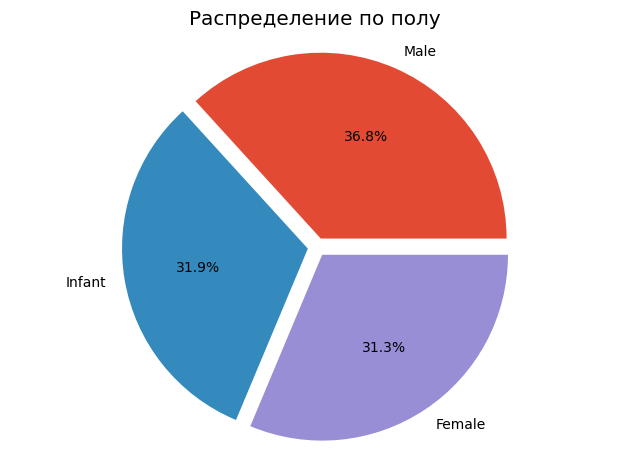

In [57]:
sex_counts = df['sex'].value_counts()

labels_map = {'M': 'Male', 'F': 'Female', 'I': 'Infant'}
labels = [labels_map.get(x, x) for x in sex_counts.index]

plt.pie(
    sex_counts.values,
    labels=labels,
    autopct='%1.1f%%',
    explode=(0.05, 0.05, 0.05)
)
plt.title('Распределение по полу')
plt.axis('equal')
plt.tight_layout()
plt.show()

**Категории сбалансированы**

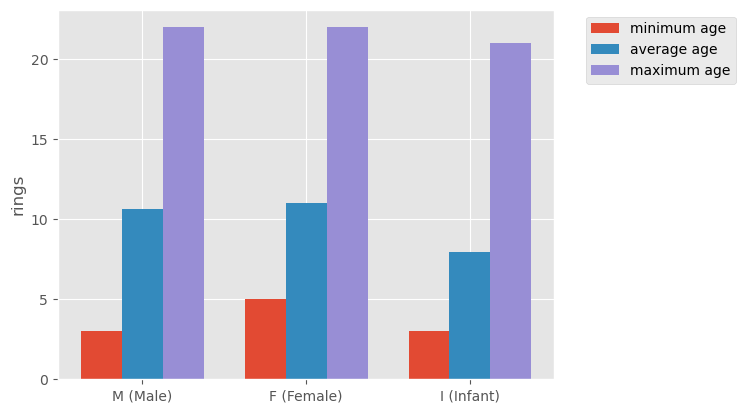

In [58]:
females = df[df['sex'] == 'F']
males = df[df['sex'] == 'M']
infants = df[df['sex'] == 'I']

stats = {
    'M (Male)': [males['rings'].min(), males['rings'].mean(), males['rings'].max()],
    'F (Female)': [females['rings'].min(), females['rings'].mean(), females['rings'].max()],
    'I (Infant)': [infants['rings'].min(), infants['rings'].mean(), infants['rings'].max()]
}

categories = list(stats.keys())
x = np.arange(len(categories))
width = 0.25

plt.bar(x - width, [stats[c][0] for c in categories], width, label='minimum age')
plt.bar(x, [stats[c][1] for c in categories], width, label='average age')
plt.bar(x + width, [stats[c][2] for c in categories], width, label='maximum age')
plt.xticks(x, labels=categories)
plt.ylabel('rings', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1))
plt.show()

**Создаю One Hot фичи**

In [59]:
sex_dummies = pd.get_dummies(df['sex'], dtype=int, drop_first=True)
df = pd.concat([df, sex_dummies], axis=1)
df = df.drop('sex', axis=1)
df

,length,diameter,height,whole weight,shucked weight,viscera weight,shell weight,rings,shell ratio,volume,I,M
0,0.455,0.365,0.095,0.716938,0.473814,0.317805,0.387298,15,0.291828,0.125607,0,1
1,0.350,0.265,0.090,0.474868,0.315436,0.220227,0.264575,7,0.310420,0.091365,0,1
2,0.530,0.420,0.135,0.822800,0.506458,0.376165,0.458258,9,0.310192,0.173352,0,0
3,0.440,0.365,0.125,0.718331,0.464220,0.337639,0.393700,10,0.300387,0.141686,0,1
4,0.330,0.255,0.080,0.452769,0.299166,0.198746,0.234521,7,0.268291,0.082049,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
4172,0.565,0.450,0.165,0.941807,0.608276,0.488876,0.498999,11,0.280721,0.204820,0,0
4173,0.590,0.440,0.135,0.982853,0.662571,0.463141,0.510392,10,0.269668,0.187206,0,1
4174,0.600,0.475,0.205,1.084435,0.724914,0.536190,0.554977,9,0.261905,0.241713,0,1
4175,0.625,0.485,0.150,1.046184,0.728697,0.510882,0.544059,10,0.270443,0.213234,0,0


# Вывод: дисбаланса категорий нет. Они близки как и по доле в датасете, так и по возрасту представителей. У категории Infant (младенцы) среднее меньше чем у остальных категорий, что логично. Сначала меня напрягло наличие 20-летних "младенцев", но как я понял это означает, что несмотря на большой возраст, моллюск репродуктивно не созрел и это нормально.

# Так как всего 3 категории, хватило 2 One Hot признака

# 5. Корреляционный анализ

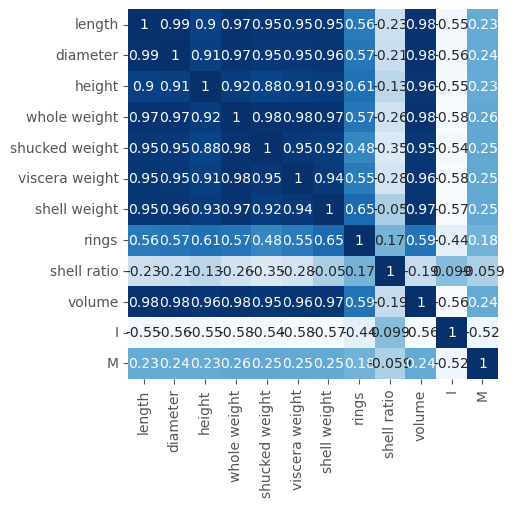

In [60]:
mat = df.corr()
sns.heatmap(mat.T, square=True, annot=True,
           cbar=False, cmap='Blues')
plt.show()

**Все физические и геометрические признаки очень сильно коррелируют между собой.**

**Наибольшая корреляция у height (0.61) и shell weight (0.65)**

# Вывод: числовые фичи сильно коррелируют между собой. Наиболее перспективные: shell weight и height.

# Искусственная фича shell ratio показала не такую сильную корреляцию (по графику было ожидаемо). volume коррелирует сильнее, чем length и diameter.
### Извлечение корня из volume для приведения к более линейному виду дало +0.04 к линейной корреляции